# Final Experiments Part 1: Context Ablation + Ensemble
**CS 593 NLP Final Project — Purdue University, Spring 2026**

Authors: Varun Chundru, Debasmita Biswas

This notebook implements two of the final experiments:

1. **Context Ablation** — Does the fine-tuned DeBERTa actually use the knowledge context,
   or is it learning surface features of the response alone? We strip the knowledge
   context from test inputs and rerun inference.

2. **Ensemble** — Combine three detection signals (DeBERTa probability,
   MC Dropout uncertainty, retrieval similarity) into a meta-classifier.
   Trained on validation, evaluated on test.

**Inputs required:**
- Fine-tuned model: `varunchundru/hallucination-detector-deberta` (HuggingFace)
- Notebook 02 test-set outputs: `update2_uncertainty_data.csv` (upload to Kaggle)

**Environment:** Kaggle Notebook with GPU (T4x2)

## 1. Setup and Imports

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from datasets import load_dataset, concatenate_datasets, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


## 2. Load HaluEval (SAME splits as notebooks 01 and 02)

Critical: we use the **exact** same preprocessing and seeds so the test set
is identical. This allows fair comparison to Update 1 / Update 2 numbers.

In [2]:
print("Loading HaluEval _samples datasets...")
dataset_qa = load_dataset("pminervini/HaluEval", "qa_samples")
dataset_dialogue = load_dataset("pminervini/HaluEval", "dialogue_samples")
dataset_summarization = load_dataset("pminervini/HaluEval", "summarization_samples")
print(f"Loaded: QA={len(dataset_qa['data'])}, Dialogue={len(dataset_dialogue['data'])}, Summ={len(dataset_summarization['data'])}")

Loading HaluEval _samples datasets...


README.md: 0.00B [00:00, ?B/s]

qa_samples/data-00000-of-00001.parquet:   0%|          | 0.00/3.43M [00:00<?, ?B/s]

Generating data split:   0%|          | 0/10000 [00:00<?, ? examples/s]

dialogue_samples/data-00000-of-00001.par(…):   0%|          | 0.00/2.83M [00:00<?, ?B/s]

Generating data split:   0%|          | 0/10000 [00:00<?, ? examples/s]

summarization_samples/data-00000-of-0000(…):   0%|          | 0.00/25.5M [00:00<?, ?B/s]

Generating data split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Loaded: QA=10000, Dialogue=10000, Summ=10000


In [3]:
# Preprocessing functions — EXACTLY matching notebook 01/02
def preprocess_qa_samples(examples):
    processed = {'text': [], 'label': [], 'task': []}
    for i in range(len(examples['knowledge'])):
        knowledge = examples['knowledge'][i]
        question = examples['question'][i]
        answer = examples['answer'][i]
        hallucination = examples['hallucination'][i]
        context = f"Question: {question}\nKnowledge: {knowledge}"
        text = f"{context}\n\nAnswer: {answer}"
        processed['text'].append(text)
        processed['label'].append(1 if hallucination == "yes" else 0)
        processed['task'].append('qa')
    return processed

def preprocess_dialogue_samples(examples):
    processed = {'text': [], 'label': [], 'task': []}
    for i in range(len(examples['dialogue_history'])):
        history = examples['dialogue_history'][i]
        knowledge = examples['knowledge'][i] if 'knowledge' in examples else ""
        response = examples['response'][i]
        hallucination = examples['hallucination'][i]
        context = f"Dialogue: {history}\nKnowledge: {knowledge}"
        text = f"{context}\n\nResponse: {response}"
        processed['text'].append(text)
        processed['label'].append(1 if hallucination == "yes" else 0)
        processed['task'].append('dialogue')
    return processed

def preprocess_summarization_samples(examples):
    processed = {'text': [], 'label': [], 'task': []}
    for i in range(len(examples['document'])):
        document = examples['document'][i]
        summary = examples['summary'][i]
        hallucination = examples['hallucination'][i]
        text = f"Document: {document[:1500]}\n\nSummary: {summary}"
        processed['text'].append(text)
        processed['label'].append(1 if hallucination == "yes" else 0)
        processed['task'].append('summarization')
    return processed

In [4]:
qa_processed = dataset_qa['data'].map(preprocess_qa_samples, batched=True, remove_columns=dataset_qa['data'].column_names)
dialogue_processed = dataset_dialogue['data'].map(preprocess_dialogue_samples, batched=True, remove_columns=dataset_dialogue['data'].column_names)
summarization_processed = dataset_summarization['data'].map(preprocess_summarization_samples, batched=True, remove_columns=dataset_summarization['data'].column_names)

combined = concatenate_datasets([qa_processed, dialogue_processed, summarization_processed])
combined = combined.shuffle(seed=42)
train_test = combined.train_test_split(test_size=0.3, seed=42)
val_test = train_test['test'].train_test_split(test_size=0.5, seed=42)

dataset_splits = DatasetDict({
    'train': train_test['train'],
    'validation': val_test['train'],
    'test': val_test['test']
})

print(f"Train: {len(dataset_splits['train'])}  Val: {len(dataset_splits['validation'])}  Test: {len(dataset_splits['test'])}")

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Train: 21000  Val: 4500  Test: 4500


## 3. Load Fine-Tuned DeBERTa

In [5]:
print("Loading fine-tuned DeBERTa from HuggingFace...")
model_name_ft = "varunchundru/hallucination-detector-deberta"
tokenizer_ft = AutoTokenizer.from_pretrained(model_name_ft)
model_ft = AutoModelForSequenceClassification.from_pretrained(model_name_ft)
model_ft = model_ft.float()
model_ft = model_ft.to(device)
print(f"Model loaded. Dtype: {next(model_ft.parameters()).dtype}")

Loading fine-tuned DeBERTa from HuggingFace...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/509 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Model loaded. Dtype: torch.float32


---
## 4. EXPERIMENT 1: Context Ablation

**Question:** Does the fine-tuned DeBERTa actually need the knowledge context?

**Setup:** Strip the knowledge/context portion of each test input, leaving only the
question/response structure, and rerun inference.

**Interpretation:**
- If performance stays ~the same → model is using surface features of the response
  (vocabulary patterns, style, etc.), not actually grounding against knowledge.
  This would be a concerning finding.
- If performance drops significantly → model genuinely uses the context.
  This validates the NLI-based detection framing.

In [6]:
def strip_context(text, task):
    """
    Remove the knowledge context, keeping only question/response.

    - QA: drop "Knowledge:" section, keep question and answer
    - Dialogue: drop "Knowledge:" section, keep history and response
    - Summarization: drop "Document:" section, keep only the summary
    """
    if task == 'qa':
        # Original: "Question: ...\nKnowledge: ...\n\nAnswer: ..."
        if "\n\nAnswer:" in text:
            header, answer_part = text.split("\n\nAnswer:", 1)
            # Keep question only
            if "Knowledge:" in header:
                question = header.split("Knowledge:")[0].strip()
            else:
                question = header
            return f"{question}\n\nAnswer:{answer_part}"
    elif task == 'dialogue':
        if "\n\nResponse:" in text:
            header, response_part = text.split("\n\nResponse:", 1)
            if "Knowledge:" in header:
                dialogue = header.split("Knowledge:")[0].strip()
            else:
                dialogue = header
            return f"{dialogue}\n\nResponse:{response_part}"
    elif task == 'summarization':
        # Original: "Document: ...\n\nSummary: ..."
        if "\n\nSummary:" in text:
            _, summary_part = text.split("\n\nSummary:", 1)
            return f"Summary:{summary_part}"
    return text

In [7]:
# Build no-context version of test set
test_texts = dataset_splits['test']['text']
test_labels = np.array(dataset_splits['test']['label'])
test_tasks = dataset_splits['test']['task']

test_texts_nocontext = [strip_context(t, task) for t, task in zip(test_texts, test_tasks)]

# Sanity check: show one example from each task
print("=== Sanity check: stripped context examples ===\n")
for task in ['qa', 'dialogue', 'summarization']:
    idx = next(i for i, t in enumerate(test_tasks) if t == task)
    print(f"--- {task.upper()} ---")
    print(f"ORIGINAL (first 250 chars):\n{test_texts[idx][:250]}")
    print(f"\nSTRIPPED:\n{test_texts_nocontext[idx][:250]}")
    print()

=== Sanity check: stripped context examples ===

--- QA ---
ORIGINAL (first 250 chars):
Question: Brackenhill Tower is a peel tower, in the parish of Arthuret, Arthuret is a civil parish in the Carlisle district of Cumbria, in which country?
Knowledge: Brackenhill Tower is a peel tower, in the parish of Arthuret, in Cumbria, just north 

STRIPPED:
Question: Brackenhill Tower is a peel tower, in the parish of Arthuret, Arthuret is a civil parish in the Carlisle district of Cumbria, in which country?

Answer: Scotland.

--- DIALOGUE ---
ORIGINAL (first 250 chars):
Dialogue: [Human]: What do you think about Britney Spears? Is she still relevant? [Assistant]: She and her friend, Madonna, are getting past their prime, don't you think? [Human]: I do think so. I haven't heard anything from either of them in forever

STRIPPED:
Dialogue: [Human]: What do you think about Britney Spears? Is she still relevant? [Assistant]: She and her friend, Madonna, are getting past their prime, don't you think

In [8]:
# Run inference on no-context test set
print("Running inference on no-context test set...")
model_ft.eval()

nocontext_probs = []
nocontext_preds = []

with torch.no_grad():
    for i in range(0, len(test_texts_nocontext), 32):
        batch = test_texts_nocontext[i:i+32]
        inputs = tokenizer_ft(
            batch, truncation=True, max_length=512,
            padding=True, return_tensors="pt"
        ).to(device)
        outputs = model_ft(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        hall_probs = probs[:, 1].cpu().numpy()
        preds = (hall_probs > 0.5).astype(int)
        nocontext_probs.extend(hall_probs.tolist())
        nocontext_preds.extend(preds.tolist())

        if (i // 32) % 25 == 0:
            print(f"  Batch {i//32 + 1}/{(len(test_texts_nocontext) + 31)//32}")

nocontext_probs = np.array(nocontext_probs)
nocontext_preds = np.array(nocontext_preds)

Running inference on no-context test set...
  Batch 1/141
  Batch 26/141
  Batch 51/141
  Batch 76/141
  Batch 101/141
  Batch 126/141


In [9]:
# Metrics — no context
acc_nc = accuracy_score(test_labels, nocontext_preds)
p_nc, r_nc, f1_nc, _ = precision_recall_fscore_support(test_labels, nocontext_preds, average="binary")
auroc_nc = roc_auc_score(test_labels, nocontext_probs)

# Reference: with-context metrics from Update 1/2 (known values on same test set)
acc_wc, p_wc, r_wc, f1_wc, auroc_wc = 0.9127, 0.8819, 0.9505, 0.9149, 0.9771

print(f"\n{'='*60}")
print(f"Context Ablation Results")
print(f"{'='*60}")
print(f"{'Metric':<12} {'With context':>15} {'No context':>15} {'Delta':>10}")
print("-" * 60)
for name, wc, nc in [
    ("Accuracy", acc_wc, acc_nc),
    ("Precision", p_wc, p_nc),
    ("Recall", r_wc, r_nc),
    ("F1", f1_wc, f1_nc),
    ("AUROC", auroc_wc, auroc_nc),
]:
    delta = nc - wc
    print(f"{name:<12} {wc:>15.4f} {nc:>15.4f} {delta:>+10.4f}")


Context Ablation Results
Metric          With context      No context      Delta
------------------------------------------------------------
Accuracy              0.9127          0.7891    -0.1236
Precision             0.8819          0.7132    -0.1687
Recall                0.9505          0.9586    +0.0081
F1                    0.9149          0.8179    -0.0970
AUROC                 0.9771          0.9367    -0.0404


In [10]:
# Per-task breakdown
print(f"\n{'='*60}")
print(f"Per-task context ablation")
print(f"{'='*60}")

context_ablation_per_task = {}
for task in ['qa', 'dialogue', 'summarization']:
    mask = np.array([t == task for t in test_tasks])
    y_true = test_labels[mask]
    y_pred_nc = nocontext_preds[mask]
    probs_nc = nocontext_probs[mask]

    acc_t = accuracy_score(y_true, y_pred_nc)
    p_t, r_t, f1_t, _ = precision_recall_fscore_support(y_true, y_pred_nc, average="binary", zero_division=0)
    auroc_t = roc_auc_score(y_true, probs_nc)
    context_ablation_per_task[task] = {'Acc': acc_t, 'P': p_t, 'R': r_t, 'F1': f1_t, 'AUROC': auroc_t}
    print(f"{task.upper():<15} Acc={acc_t:.4f}  P={p_t:.4f}  R={r_t:.4f}  F1={f1_t:.4f}  AUROC={auroc_t:.4f}")

# With-context per-task from Update 1/2 (known)
wc_per_task = {
    'qa':            {'Acc': 0.97, 'F1': 0.97},
    'dialogue':      {'Acc': 0.82, 'F1': 0.82},
    'summarization': {'Acc': 0.96, 'F1': 0.96},
}
print(f"\nF1 comparison by task:")
print(f"{'Task':<15} {'With ctx':>12} {'No ctx':>12} {'Delta':>10}")
for task in ['qa', 'dialogue', 'summarization']:
    f1_wc_t = wc_per_task[task]['F1']
    f1_nc_t = context_ablation_per_task[task]['F1']
    print(f"{task.upper():<15} {f1_wc_t:>12.4f} {f1_nc_t:>12.4f} {f1_nc_t - f1_wc_t:>+10.4f}")


Per-task context ablation
QA              Acc=0.9616  P=0.9700  R=0.9563  F1=0.9631  AUROC=0.9815
DIALOGUE        Acc=0.7746  P=0.6966  R=0.9230  F1=0.7940  AUROC=0.9057
SUMMARIZATION   Acc=0.6328  P=0.5710  R=0.9959  F1=0.7258  AUROC=0.9767

F1 comparison by task:
Task                With ctx       No ctx      Delta
QA                    0.9700       0.9631    -0.0069
DIALOGUE              0.8200       0.7940    -0.0260
SUMMARIZATION         0.9600       0.7258    -0.2342


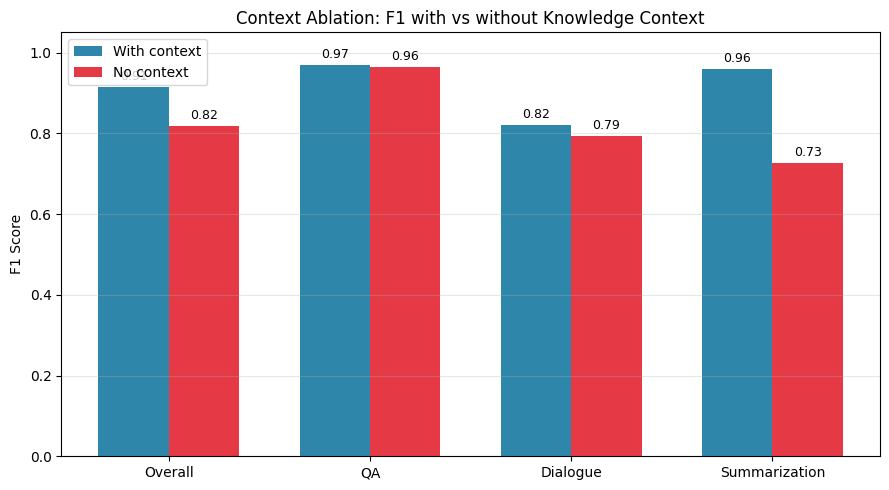

Saved: context_ablation.png


In [11]:
# Visualization: bar chart of F1 with vs without context
fig, ax = plt.subplots(figsize=(9, 5))
tasks = ['Overall', 'QA', 'Dialogue', 'Summarization']
f1_with = [f1_wc, 0.97, 0.82, 0.96]
f1_without = [f1_nc] + [context_ablation_per_task[t]['F1'] for t in ['qa', 'dialogue', 'summarization']]

x = np.arange(len(tasks))
w = 0.35
bars1 = ax.bar(x - w/2, f1_with, w, label='With context', color='#2E86AB')
bars2 = ax.bar(x + w/2, f1_without, w, label='No context', color='#E63946')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f'{height:.2f}',
                ha='center', va='bottom', fontsize=9)

ax.set_ylabel('F1 Score')
ax.set_title('Context Ablation: F1 with vs without Knowledge Context')
ax.set_xticks(x)
ax.set_xticklabels(tasks)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("context_ablation.png", dpi=150)
plt.show()
print("Saved: context_ablation.png")

---
## 5. EXPERIMENT 2: Ensemble

**Goal:** Combine three detection signals into a meta-classifier:
1. Fine-tuned DeBERTa probability
2. MC Dropout mean probability + uncertainty (std)
3. Retrieval similarity (MiniLM cosine)

**Approach:**
- We already have these signals for the test set (from notebook 02, saved as
  `update2_uncertainty_data.csv`).
- We need the same signals for the validation set to train the meta-classifier.
- We'll compute validation-set signals, train a Logistic Regression meta-classifier,
  then evaluate on the held-out test set.

### 5.1 Load test-set signals from notebook 02 output

In [12]:
# Expected columns: label, task, standard_prob, mc_mean_prob, mc_uncertainty,
#                   retrieval_similarity, calibrated_prob
try:
    test_signals_df = pd.read_csv("/kaggle/input/datasets/varuntejml/update2-uncertainty-data/update2_uncertainty_data.csv")
    print(f"Loaded test-set signals: {test_signals_df.shape}")
    print(f"Columns: {list(test_signals_df.columns)}")
except FileNotFoundError:
    print("ERROR: update2_uncertainty_data.csv not found.")
    print("Upload it as a Kaggle dataset named 'update2-uncertainty-data' and re-run this cell.")
    raise

# Sanity check: labels should match the current test split
assert len(test_signals_df) == len(test_labels), \
    f"Mismatch: test_signals_df has {len(test_signals_df)} rows but test set has {len(test_labels)}"
assert (test_signals_df['label'].values == test_labels).all(), \
    "Labels in CSV don't match current test split — seed/split mismatch!"
print("Signal file matches current test split.")

Loaded test-set signals: (4500, 10)
Columns: ['label', 'task', 'standard_prob', 'standard_pred', 'mc_mean_prob', 'mc_pred', 'mc_uncertainty', 'retrieval_similarity', 'calibrated_prob', 'calibrated_pred']
Signal file matches current test split.


In [13]:
val_texts = dataset_splits['validation']['text']
val_labels = np.array(dataset_splits['validation']['label'])
val_tasks = dataset_splits['validation']['task']

print(f"Validation set: {len(val_texts)} samples")

Validation set: 4500 samples


In [14]:
# Enable DataParallel if multiple GPUs
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs with DataParallel")
    model_ft = nn.DataParallel(model_ft)

Using 2 GPUs with DataParallel


In [15]:
# Signal 1: Standard DeBERTa probability on validation
print("Computing standard DeBERTa probs on validation...")
model_ft.eval()
val_standard_probs = []

with torch.no_grad():
    for i in range(0, len(val_texts), 32):
        batch = val_texts[i:i+32]
        inputs = tokenizer_ft(
            batch, truncation=True, max_length=512,
            padding=True, return_tensors="pt"
        ).to(device)
        outputs = model_ft(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        val_standard_probs.extend(probs[:, 1].cpu().numpy().tolist())

        if (i // 32) % 30 == 0:
            print(f"  Batch {i//32 + 1}/{(len(val_texts) + 31)//32}")

val_standard_probs = np.array(val_standard_probs)
print(f"Done. Mean prob: {val_standard_probs.mean():.4f}")

Computing standard DeBERTa probs on validation...
  Batch 1/141
  Batch 31/141
  Batch 61/141
  Batch 91/141
  Batch 121/141
Done. Mean prob: 0.5531


In [16]:
# Signal 2: MC Dropout on validation (20 passes)
print("Computing MC Dropout on validation (20 passes)...")


def mc_dropout_predict(model, tokenizer, texts, n_samples=20, batch_size=32, max_length=512):
    model.train()  # enables dropout at inference
    all_pass_probs = []

    for sample_idx in range(n_samples):
        pass_probs = []
        with torch.no_grad():
            for i in range(0, len(texts), batch_size):
                batch_texts = texts[i:i + batch_size]
                inputs = tokenizer(
                    batch_texts, truncation=True, max_length=max_length,
                    padding=True, return_tensors="pt"
                ).to(device)
                outputs = model(**inputs)
                probs = torch.softmax(outputs.logits, dim=-1)
                pass_probs.extend(probs[:, 1].cpu().numpy().tolist())
        all_pass_probs.append(pass_probs)
        if (sample_idx + 1) % 5 == 0:
            print(f"  MC pass {sample_idx + 1}/{n_samples}")

    all_pass_probs = np.array(all_pass_probs)
    mean_probs = np.mean(all_pass_probs, axis=0)
    uncertainty = np.std(all_pass_probs, axis=0)

    model.eval()
    return mean_probs, uncertainty


val_mc_mean, val_mc_uncertainty = mc_dropout_predict(
    model_ft, tokenizer_ft, val_texts, n_samples=20, batch_size=256
)
print(f"Done. Mean uncertainty: {val_mc_uncertainty.mean():.4f}")

Computing MC Dropout on validation (20 passes)...
  MC pass 5/20
  MC pass 10/20
  MC pass 15/20
  MC pass 20/20
Done. Mean uncertainty: 0.0339


In [17]:
# Signal 3: Retrieval similarity on validation
print("Computing retrieval similarity on validation...")

try:
    from sentence_transformers import SentenceTransformer, util
except ImportError:
    os.system("pip install sentence-transformers --quiet")
    from sentence_transformers import SentenceTransformer, util

retriever = SentenceTransformer("all-MiniLM-L6-v2")


def extract_knowledge_and_response(text):
    """Match notebook 02's extraction logic."""
    knowledge = ""
    response = ""
    if "Answer:" in text:
        parts = text.split("\n\nAnswer:")
        if len(parts) == 2:
            response = parts[1].strip()
            header = parts[0]
            if "Knowledge:" in header:
                knowledge = header.split("Knowledge:")[1].strip()
            else:
                knowledge = header
    elif "Response:" in text:
        parts = text.split("\n\nResponse:")
        if len(parts) == 2:
            response = parts[1].strip()
            header = parts[0]
            if "Knowledge:" in header:
                knowledge = header.split("Knowledge:")[1].strip()
            else:
                knowledge = header
    elif "Summary:" in text:
        parts = text.split("\n\nSummary:")
        if len(parts) == 2:
            response = parts[1].strip()
            knowledge = parts[0].replace("Document:", "").strip()
    else:
        knowledge = text
        response = text
    return knowledge, response


val_knowledges = []
val_responses = []
for text in val_texts:
    k, r = extract_knowledge_and_response(text)
    val_knowledges.append(k)
    val_responses.append(r)

print(f"Encoding {len(val_knowledges)} knowledge texts...")
val_k_emb = retriever.encode(val_knowledges, batch_size=64, show_progress_bar=True)
print(f"Encoding {len(val_responses)} response texts...")
val_r_emb = retriever.encode(val_responses, batch_size=64, show_progress_bar=True)

val_retrieval_sim = np.array([
    util.cos_sim(val_k_emb[i], val_r_emb[i]).item()
    for i in range(len(val_knowledges))
])
print(f"Done. Mean similarity: {val_retrieval_sim.mean():.4f}")

Computing retrieval similarity on validation...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Encoding 4500 knowledge texts...


Batches:   0%|          | 0/71 [00:00<?, ?it/s]

Encoding 4500 response texts...


Batches:   0%|          | 0/71 [00:00<?, ?it/s]

Done. Mean similarity: 0.5412


### 5.3 Train meta-classifier on validation, evaluate on test

In [18]:
# Feature matrix for validation (training the meta-classifier)
X_val = np.column_stack([
    val_standard_probs,     # DeBERTa standard probability
    val_mc_mean,            # MC Dropout mean probability
    val_mc_uncertainty,     # MC Dropout uncertainty (std)
    val_retrieval_sim,      # Retrieval similarity
])
y_val = val_labels

# Feature matrix for test (evaluation)
X_test = np.column_stack([
    test_signals_df['standard_prob'].values,
    test_signals_df['mc_mean_prob'].values,
    test_signals_df['mc_uncertainty'].values,
    test_signals_df['retrieval_similarity'].values,
])
y_test = test_signals_df['label'].values

feature_names = ['deberta_prob', 'mc_mean', 'mc_uncertainty', 'retrieval_sim']

print(f"X_val: {X_val.shape}, X_test: {X_test.shape}")

X_val: (4500, 4), X_test: (4500, 4)


In [19]:
# Train meta-classifier (Logistic Regression)
print("\nTraining Logistic Regression meta-classifier on validation set...")
meta_clf = LogisticRegression(max_iter=1000, random_state=42)
meta_clf.fit(X_val, y_val)

ens_probs = meta_clf.predict_proba(X_test)[:, 1]
ens_preds = (ens_probs > 0.5).astype(int)

acc_ens = accuracy_score(y_test, ens_preds)
p_ens, r_ens, f1_ens, _ = precision_recall_fscore_support(y_test, ens_preds, average="binary")
auroc_ens = roc_auc_score(y_test, ens_probs)

print(f"\n{'='*60}")
print(f"Ensemble Results (Logistic Regression meta-classifier)")
print(f"{'='*60}")
print(f"Accuracy:  {acc_ens:.4f}")
print(f"Precision: {p_ens:.4f}")
print(f"Recall:    {r_ens:.4f}")
print(f"F1 Score:  {f1_ens:.4f}")
print(f"AUROC:     {auroc_ens:.4f}")

print(f"\nLearned meta-classifier weights:")
for name, coef in zip(feature_names, meta_clf.coef_[0]):
    print(f"  {name:<20} {coef:+.4f}")
print(f"  {'intercept':<20} {meta_clf.intercept_[0]:+.4f}")


Training Logistic Regression meta-classifier on validation set...

Ensemble Results (Logistic Regression meta-classifier)
Accuracy:  0.9311
Precision: 0.9386
Recall:    0.9208
F1 Score:  0.9296
AUROC:     0.9596

Learned meta-classifier weights:
  deberta_prob         +2.6579
  mc_mean              +3.2702
  mc_uncertainty       -3.8332
  retrieval_sim        +0.3432
  intercept            -3.1046


In [20]:
# Simple ensemble strategies for comparison
print(f"\n{'='*60}")
print(f"Comparison: individual signals and simple ensembles")
print(f"{'='*60}")

strategies = {}

# Individual signals
for name, col in [
    ('DeBERTa alone',   'standard_prob'),
    ('MC Dropout mean', 'mc_mean_prob'),
    ('Calibrated',      'calibrated_prob'),
]:
    probs = test_signals_df[col].values
    preds = (probs > 0.5).astype(int)
    acc = accuracy_score(y_test, preds)
    _, _, f1, _ = precision_recall_fscore_support(y_test, preds, average="binary")
    auroc = roc_auc_score(y_test, probs)
    strategies[name] = {'Acc': acc, 'F1': f1, 'AUROC': auroc}

# Simple average (DeBERTa + MC mean)
avg_probs = (test_signals_df['standard_prob'].values + test_signals_df['mc_mean_prob'].values) / 2
avg_preds = (avg_probs > 0.5).astype(int)
acc_avg = accuracy_score(y_test, avg_preds)
_, _, f1_avg, _ = precision_recall_fscore_support(y_test, avg_preds, average="binary")
auroc_avg = roc_auc_score(y_test, avg_probs)
strategies['Simple Average (DeBERTa + MC)'] = {'Acc': acc_avg, 'F1': f1_avg, 'AUROC': auroc_avg}

# Logistic Regression meta-classifier (4 features)
strategies['LR meta-classifier (all 4)'] = {'Acc': acc_ens, 'F1': f1_ens, 'AUROC': auroc_ens}

# Pretty print
print(f"\n{'Strategy':<35} {'Acc':>8} {'F1':>8} {'AUROC':>8}")
print("-" * 65)
for name, m in strategies.items():
    print(f"{name:<35} {m['Acc']:>8.4f} {m['F1']:>8.4f} {m['AUROC']:>8.4f}")


Comparison: individual signals and simple ensembles

Strategy                                 Acc       F1    AUROC
-----------------------------------------------------------------
DeBERTa alone                         0.9127   0.9149   0.9771
MC Dropout mean                       0.9318   0.9307   0.9784
Calibrated                            0.9127   0.9149   0.9771
Simple Average (DeBERTa + MC)         0.9200   0.9213   0.9785
LR meta-classifier (all 4)            0.9311   0.9296   0.9596


In [21]:
# Ablation: which features contribute most?
print(f"\n{'='*60}")
print(f"Feature importance ablation (LR meta-classifier)")
print(f"{'='*60}")

feature_ablations = {}
for drop_idx in range(len(feature_names)):
    keep_features = [i for i in range(len(feature_names)) if i != drop_idx]
    X_val_subset = X_val[:, keep_features]
    X_test_subset = X_test[:, keep_features]

    meta_clf_ab = LogisticRegression(max_iter=1000, random_state=42)
    meta_clf_ab.fit(X_val_subset, y_val)
    probs_ab = meta_clf_ab.predict_proba(X_test_subset)[:, 1]
    preds_ab = (probs_ab > 0.5).astype(int)
    _, _, f1_ab, _ = precision_recall_fscore_support(y_test, preds_ab, average="binary")
    auroc_ab = roc_auc_score(y_test, probs_ab)
    dropped = feature_names[drop_idx]
    feature_ablations[dropped] = {'F1': f1_ab, 'AUROC': auroc_ab}
    f1_delta = f1_ab - f1_ens
    auroc_delta = auroc_ab - auroc_ens
    print(f"  Without {dropped:<18} F1={f1_ab:.4f} ({f1_delta:+.4f})  AUROC={auroc_ab:.4f} ({auroc_delta:+.4f})")


Feature importance ablation (LR meta-classifier)
  Without deberta_prob       F1=0.9292 (-0.0004)  AUROC=0.9669 (+0.0073)
  Without mc_mean            F1=0.9206 (-0.0090)  AUROC=0.9552 (-0.0044)
  Without mc_uncertainty     F1=0.9289 (-0.0007)  AUROC=0.9666 (+0.0070)
  Without retrieval_sim      F1=0.9288 (-0.0008)  AUROC=0.9710 (+0.0114)


## 6. Save all artifacts

In [22]:
# Save context ablation data
context_df = pd.DataFrame({
    'label': test_labels,
    'task': test_tasks,
    'nocontext_prob': nocontext_probs,
    'nocontext_pred': nocontext_preds,
})
context_df.to_csv("context_ablation_predictions.csv", index=False)

# Save validation signals (for reproducibility)
val_signals_df = pd.DataFrame({
    'label': val_labels,
    'task': val_tasks,
    'standard_prob': val_standard_probs,
    'mc_mean_prob': val_mc_mean,
    'mc_uncertainty': val_mc_uncertainty,
    'retrieval_similarity': val_retrieval_sim,
})
val_signals_df.to_csv("validation_signals.csv", index=False)

# Save ensemble predictions
ensemble_df = pd.DataFrame({
    'label': y_test,
    'ensemble_prob': ens_probs,
    'ensemble_pred': ens_preds,
})
ensemble_df.to_csv("ensemble_predictions.csv", index=False)

# Save summary results
results_summary = pd.DataFrame({
    'Experiment': [
        'With context (Update 1/2)',
        'Context ablation (no knowledge)',
        'DeBERTa alone',
        'MC Dropout mean',
        'Calibrated DeBERTa',
        'Simple Average (DeBERTa + MC)',
        'LR meta-classifier (all 4 features)',
    ],
    'Accuracy': [acc_wc, acc_nc,
                 strategies['DeBERTa alone']['Acc'],
                 strategies['MC Dropout mean']['Acc'],
                 strategies['Calibrated']['Acc'],
                 strategies['Simple Average (DeBERTa + MC)']['Acc'],
                 strategies['LR meta-classifier (all 4)']['Acc']],
    'F1': [f1_wc, f1_nc,
           strategies['DeBERTa alone']['F1'],
           strategies['MC Dropout mean']['F1'],
           strategies['Calibrated']['F1'],
           strategies['Simple Average (DeBERTa + MC)']['F1'],
           strategies['LR meta-classifier (all 4)']['F1']],
    'AUROC': [auroc_wc, auroc_nc,
              strategies['DeBERTa alone']['AUROC'],
              strategies['MC Dropout mean']['AUROC'],
              strategies['Calibrated']['AUROC'],
              strategies['Simple Average (DeBERTa + MC)']['AUROC'],
              strategies['LR meta-classifier (all 4)']['AUROC']],
})
results_summary.to_csv("final_notebook03_results.csv", index=False)

print("\nSaved artifacts:")
print("  - context_ablation.png")
print("  - context_ablation_predictions.csv")
print("  - validation_signals.csv")
print("  - ensemble_predictions.csv")
print("  - final_notebook03_results.csv")


Saved artifacts:
  - context_ablation.png
  - context_ablation_predictions.csv
  - validation_signals.csv
  - ensemble_predictions.csv
  - final_notebook03_results.csv
